Student Name: Jennylynne Saladino    
Student ID: C0929140

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor



In [6]:
# Load data
df = pd.read_csv('cars.csv')  # adjust filename if different

# View basic info
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         762091 non-null  object 
 1   model                762091 non-null  object 
 2   year                 762091 non-null  int64  
 3   mileage              761585 non-null  float64
 4   engine               747041 non-null  object 
 5   transmission         752187 non-null  object 
 6   drivetrain           740529 non-null  object 
 7   fuel_type            739164 non-null  object 
 8   mpg                  620020 non-null  object 
 9   exterior_color       753232 non-null  object 
 10  interior_color       705116 non-null  object 
 11  accidents_or_damage  737879 non-null  float64
 12  one_owner            730608 non-null  float64
 13  personal_use_only    737239 non-null  float64
 14  seller_name          753498 non-null  object 
 15  seller_rating    

,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price
count,762091.000000,7.615850e+05,737879.000000,730608.000000,737239.000000,548118.000000,730459.000000,762091.000000,410112.000000,7.620910e+05
mean,2017.791398,5.578169e+04,0.228616,0.561969,0.657212,4.158568,4.623523,89.550900,1007.467068,3.648898e+04
std,5.110532,4.355788e+04,0.419942,0.496145,0.474642,0.805741,0.276902,115.082266,1375.122208,1.984183e+06
min,1915.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,100.000000,1.000000e+00
25%,2016.000000,2.328700e+04,0.000000,0.000000,0.000000,3.800000,4.500000,14.000000,380.000000,1.958300e+04
50%,2019.000000,4.559600e+04,0.000000,1.000000,1.000000,4.500000,4.700000,51.000000,642.000000,2.798900e+04
75%,2021.000000,7.836500e+04,0.000000,1.000000,1.000000,4.700000,4.800000,119.000000,1007.000000,3.948800e+04
max,2024.000000,1.119067e+06,1.000000,1.000000,1.000000,5.000000,5.000000,1025.000000,170995.000000,1.000000e+09


In [7]:
# Sample 10% of data from each manufacturer group
df_sampling = df.groupby('manufacturer', group_keys=False).sample(frac=0.1, random_state=42)

# Reset index for neatness
df_sampling = df_sampling.reset_index(drop=True)

print(df_sampling['manufacturer'].value_counts())  # Check the counts
print(df_sampling.shape)

df_sampling = df.groupby('manufacturer', group_keys=False).sample(frac=0.1, random_state=42)



manufacturer
Ford             7953
Toyota           5954
Chevrolet        5604
Nissan           4853
Jeep             4166
Mercedes-Benz    4082
Honda            3761
BMW              3757
Kia              3506
GMC              2956
Dodge            2525
Subaru           2477
Volkswagen       2462
Hyundai          2220
Lexus            2130
RAM              1936
Audi             1786
Cadillac         1779
Mazda            1548
Buick            1462
Chrysler         1265
INFINITI         1229
Land Rover       1227
Porsche          1146
Lincoln          1061
Volvo            1003
Acura             849
Tesla             588
Mitsubishi        574
Jaguar            347
Name: count, dtype: int64
(76206, 20)


In [8]:
df_sampling.isnull().sum()         # Number of nulls per column

,0
manufacturer,0
model,0
year,0
mileage,58
engine,1458
transmission,978
drivetrain,2089
fuel_type,2319
mpg,14212
exterior_color,877


In [9]:
df_sampling.isnull().mean() * 100  # Percent of nulls per column

,0
manufacturer,0.000000
model,0.000000
year,0.000000
mileage,0.076109
engine,1.913235
transmission,1.283364
drivetrain,2.741254
fuel_type,3.043067
mpg,18.649450
exterior_color,1.150828


In [10]:
df_sampling.drop_duplicates(inplace=True)

In [11]:
# Dropping these features with high missing data and not useful for the analysis
irrelevant_features = [
    'mpg',
    'seller_rating',
    'price_drop',
    'seller_name',
    'engine',
    'transmission',
    'drivetrain',
    'driver_reviews_num',
    'exterior_color',
    'interior_color'
]

df = df_sampling.drop(columns=irrelevant_features)

df.head()

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,driver_rating,price
1905,Acura,TL 3.5,2013,107698.0,Gasoline,0.0,0.0,0.0,4.7,12695.0
5642,Acura,TLX A-Spec,2022,7863.0,Gasoline,0.0,1.0,1.0,4.8,41995.0
5735,Acura,TLX FWD,2016,66258.0,Gasoline,0.0,0.0,1.0,4.5,18498.0
8444,Acura,MDX Touring,2003,144352.0,Gasoline,1.0,1.0,1.0,4.4,6839.0
360,Acura,ILX Premium Package,2020,21086.0,Gasoline,0.0,1.0,1.0,4.6,22847.0


In [12]:
# Convert to string dtype
string_cols = [
    'manufacturer', 'model', 'fuel_type'
]
df[string_cols] = df[string_cols].astype('string')

# Convert to nullable integer (Int64)
int_cols = [
    'mileage', 'accidents_or_damage', 'one_owner', 'personal_use_only'
]
df[int_cols] = df[int_cols].astype('Int64')

df.info()
df.isnull().mean() * 100

<class 'pandas.core.frame.DataFrame'>
Index: 76110 entries, 1905 to 761947
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   manufacturer         76110 non-null  string 
 1   model                76110 non-null  string 
 2   year                 76110 non-null  int64  
 3   mileage              76052 non-null  Int64  
 4   fuel_type            73802 non-null  string 
 5   accidents_or_damage  73717 non-null  Int64  
 6   one_owner            72974 non-null  Int64  
 7   personal_use_only    73647 non-null  Int64  
 8   driver_rating        72940 non-null  float64
 9   price                76110 non-null  float64
dtypes: Int64(4), float64(2), int64(1), string(3)
memory usage: 6.7 MB


,0
manufacturer,0.000000
model,0.000000
year,0.000000
mileage,0.076205
fuel_type,3.032453
accidents_or_damage,3.144133
one_owner,4.120352
personal_use_only,3.236106
driver_rating,4.165024
price,0.000000


In [13]:
# 1. Impute mean for mileage
df['mileage'] = df['mileage'].fillna(df['mileage'].mean().round()).astype('int64')

# 2. Impute 1 for binary columns (worst case)
binary_cols = ['accidents_or_damage', 'one_owner', 'personal_use_only']
for col in binary_cols:
    df[col] = df[col].fillna(1)

# 3. Impute 0 for driver_rating
df['driver_rating'] = df['driver_rating'].fillna(0)

df.info()
df.isnull().mean() * 100

<class 'pandas.core.frame.DataFrame'>
Index: 76110 entries, 1905 to 761947
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   manufacturer         76110 non-null  string 
 1   model                76110 non-null  string 
 2   year                 76110 non-null  int64  
 3   mileage              76110 non-null  int64  
 4   fuel_type            73802 non-null  string 
 5   accidents_or_damage  76110 non-null  Int64  
 6   one_owner            76110 non-null  Int64  
 7   personal_use_only    76110 non-null  Int64  
 8   driver_rating        76110 non-null  float64
 9   price                76110 non-null  float64
dtypes: Int64(3), float64(2), int64(2), string(3)
memory usage: 6.6 MB


,0
manufacturer,0.000000
model,0.000000
year,0.000000
mileage,0.000000
fuel_type,3.032453
accidents_or_damage,0.000000
one_owner,0.000000
personal_use_only,0.000000
driver_rating,0.000000
price,0.000000


In [14]:
print("Rows before dropping missing:", len(df))
df = df.dropna()
print("Rows after dropping missing:", len(df))

df.info()
df.isnull().values.any()
df.head()

Rows before dropping missing: 76110
Rows after dropping missing: 73802
<class 'pandas.core.frame.DataFrame'>
Index: 73802 entries, 1905 to 761947
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   manufacturer         73802 non-null  string 
 1   model                73802 non-null  string 
 2   year                 73802 non-null  int64  
 3   mileage              73802 non-null  int64  
 4   fuel_type            73802 non-null  string 
 5   accidents_or_damage  73802 non-null  Int64  
 6   one_owner            73802 non-null  Int64  
 7   personal_use_only    73802 non-null  Int64  
 8   driver_rating        73802 non-null  float64
 9   price                73802 non-null  float64
dtypes: Int64(3), float64(2), int64(2), string(3)
memory usage: 6.4 MB


,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,driver_rating,price
1905,Acura,TL 3.5,2013,107698,Gasoline,0,0,0,4.7,12695.0
5642,Acura,TLX A-Spec,2022,7863,Gasoline,0,1,1,4.8,41995.0
5735,Acura,TLX FWD,2016,66258,Gasoline,0,0,1,4.5,18498.0
8444,Acura,MDX Touring,2003,144352,Gasoline,1,1,1,4.4,6839.0
360,Acura,ILX Premium Package,2020,21086,Gasoline,0,1,1,4.6,22847.0


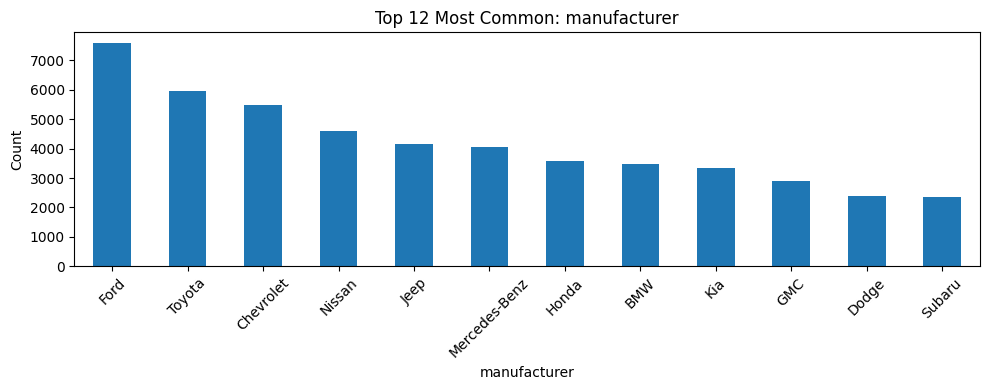

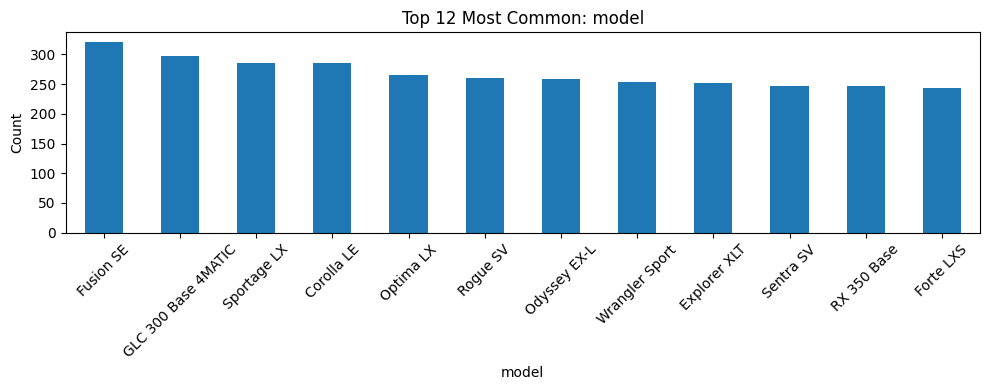

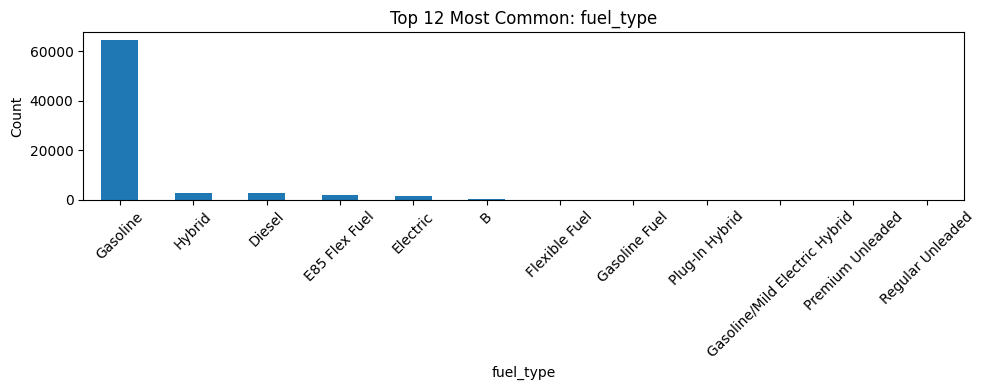

In [15]:
categorical_cols = [
    'manufacturer', 'model', 'fuel_type'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().head(12).plot(kind='bar')
    plt.title(f"Top 12 Most Common: {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

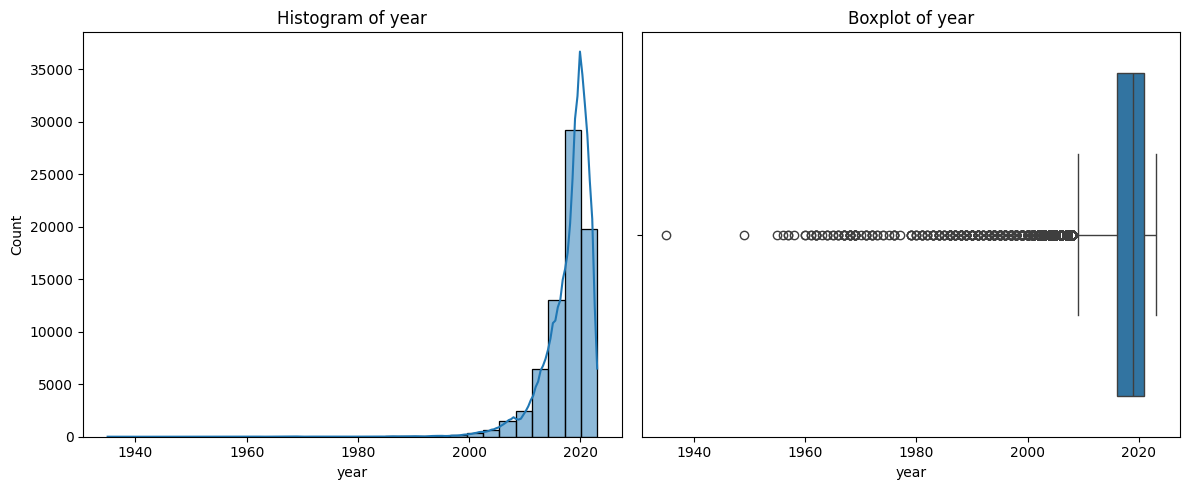

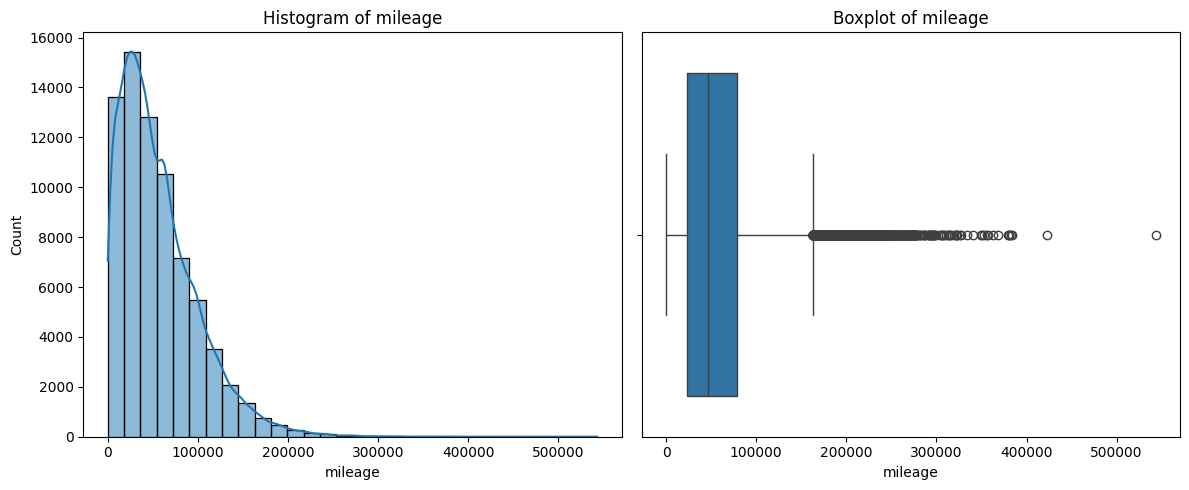

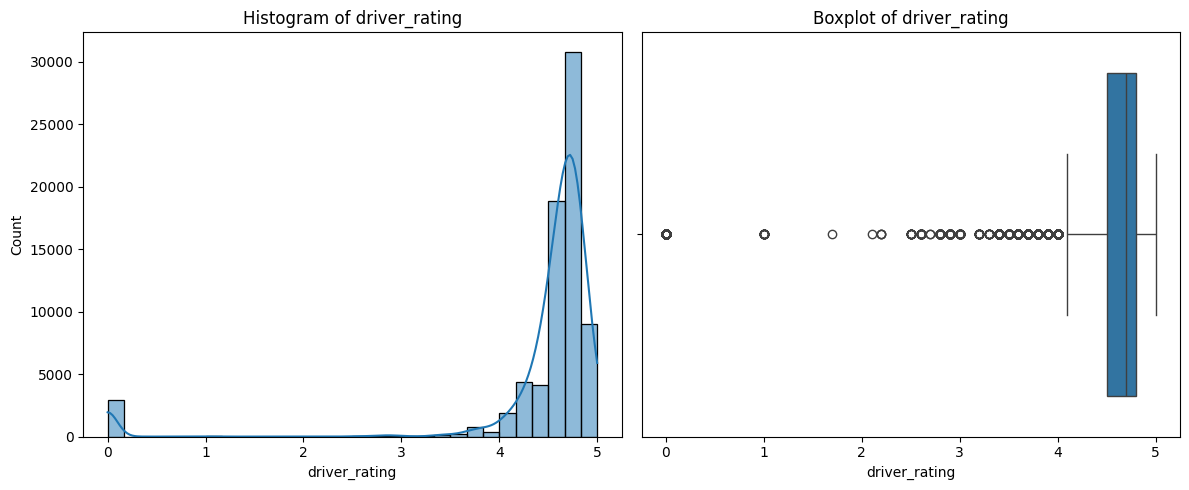

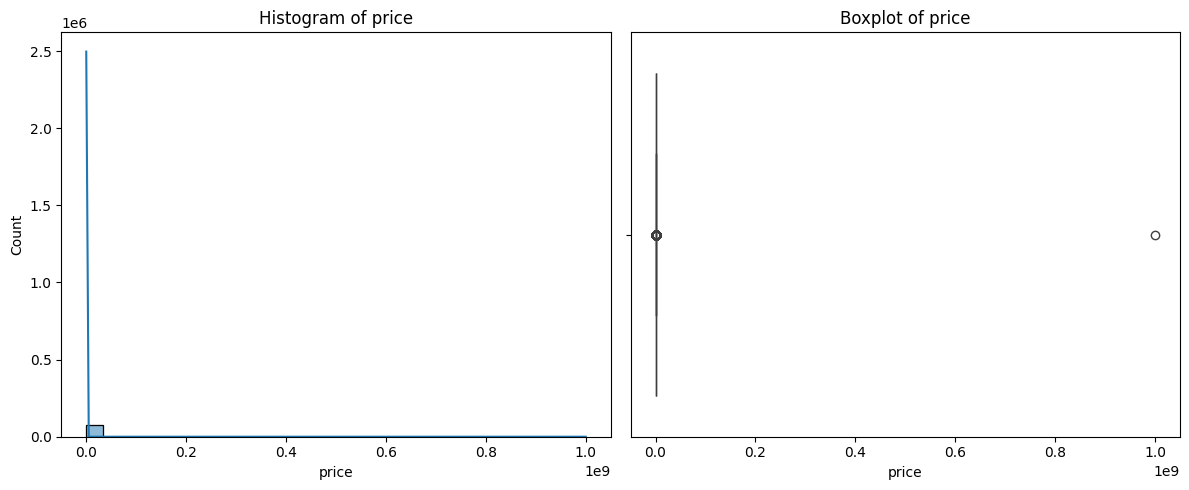

In [16]:
numeric_cols = ['year', 'mileage', 'driver_rating', 'price']

for col in numeric_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()


In [17]:
#df['price'].sort_values(ascending=False).head(10)
#df['price'].value_counts().head(10)

# Top 10 highest prices and their counts
top_10_prices = df['price'].sort_values(ascending=False).unique()[:10]
print("Top 10 highest prices and their counts:")
for price in top_10_prices:
    count = (df['price'] == price).sum()
    print(f"Price: {price}, Count: {count}")

# Count of prices above 900,000
count_above_900k = (df['price'] > 900000).sum()
print(f"\nNumber of records with price above 900,000: {count_above_900k}")


Top 10 highest prices and their counts:
Price: 1000000000.0, Count: 1
Price: 750000.0, Count: 1
Price: 529950.0, Count: 1
Price: 510000.0, Count: 1
Price: 500000.0, Count: 1
Price: 490000.0, Count: 1
Price: 489000.0, Count: 1
Price: 439990.0, Count: 1
Price: 426995.0, Count: 1
Price: 409990.0, Count: 1

Number of records with price above 900,000: 1


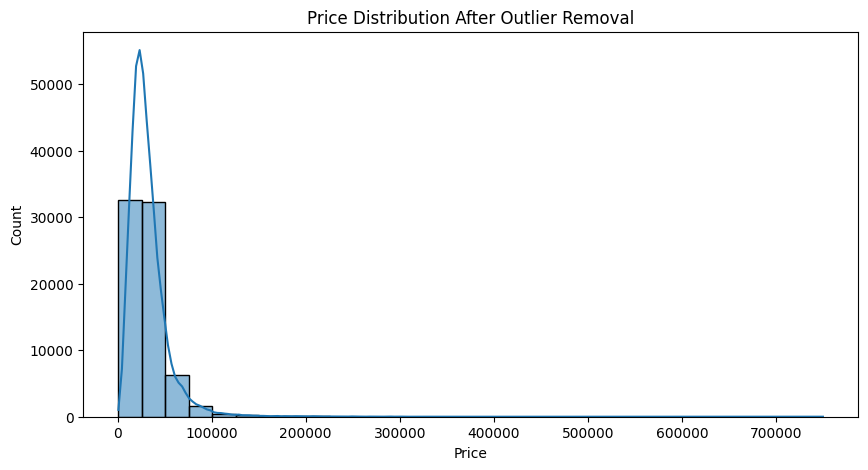

In [18]:
df_no_outlier = df[df['price'] < 900000]  # Adjust as needed

plt.figure(figsize=(10,5))
sns.histplot(df_no_outlier['price'], bins=30, kde=True)
plt.title('Price Distribution After Outlier Removal')
plt.xlabel('Price')
plt.show()

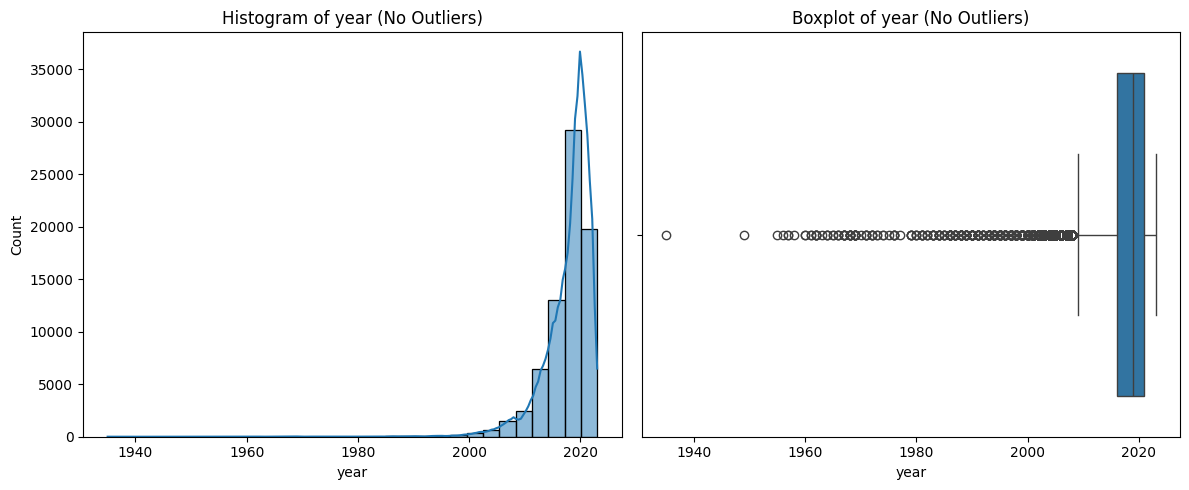

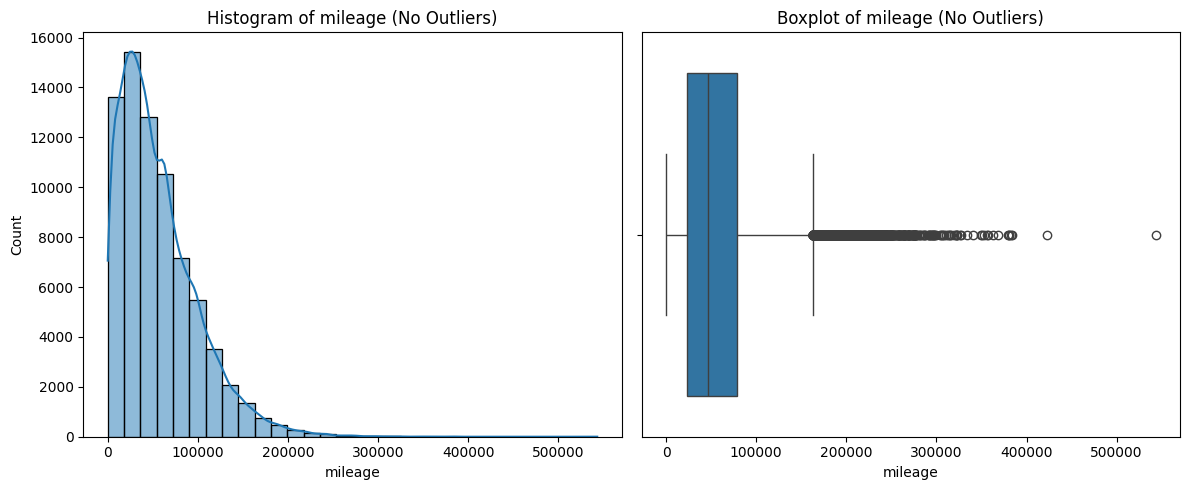

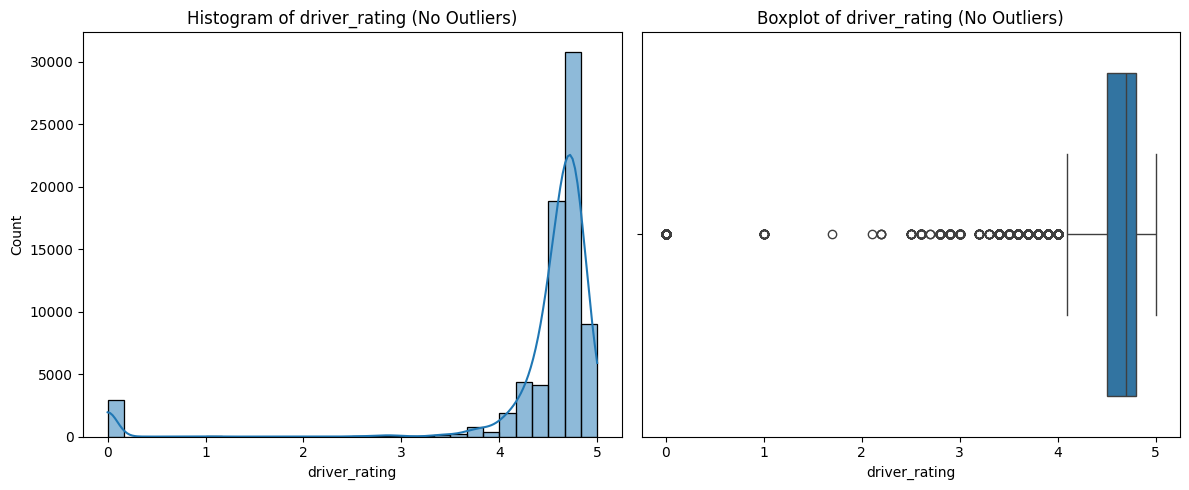

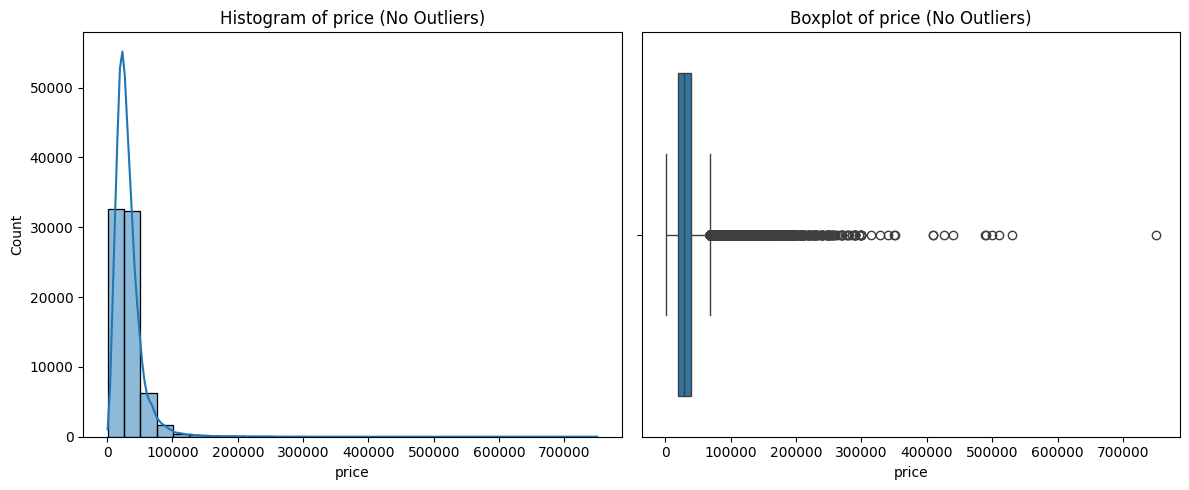

In [19]:
cols = ['year', 'mileage', 'driver_rating', 'price']

for col in cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_no_outlier[col], bins=30, kde=True)
    plt.title(f"Histogram of {col} (No Outliers)")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_no_outlier[col])
    plt.title(f"Boxplot of {col} (No Outliers)")

    plt.tight_layout()
    plt.show()


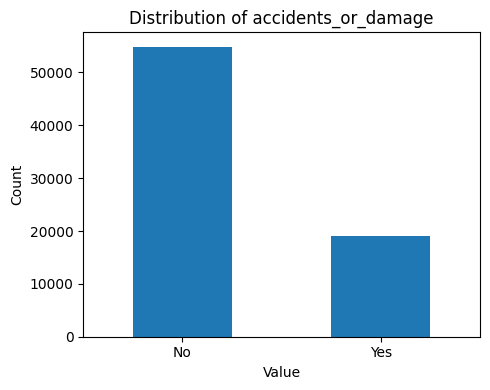

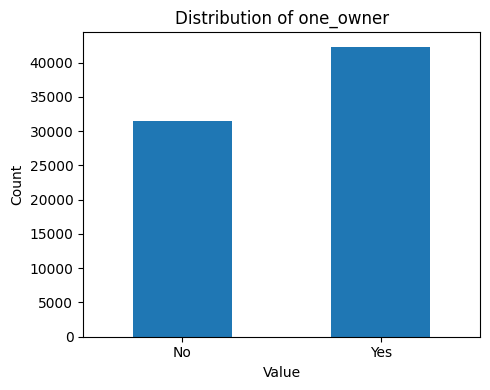

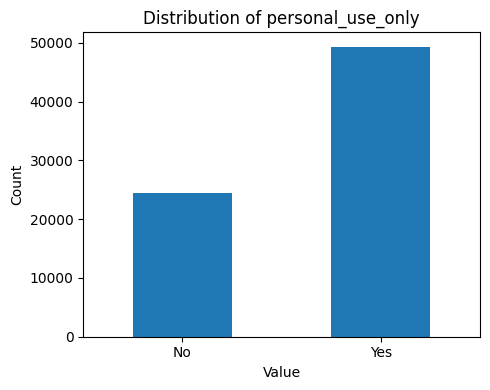

In [20]:
binary_cols = ['accidents_or_damage', 'one_owner', 'personal_use_only']

for col in binary_cols:
    plt.figure(figsize=(5, 4))
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
    plt.tight_layout()
    plt.show()


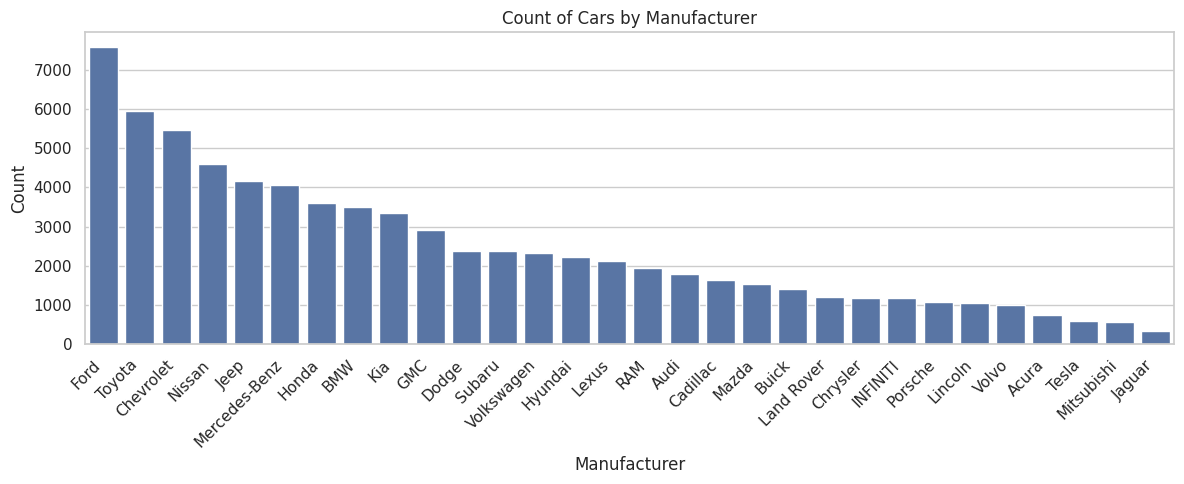

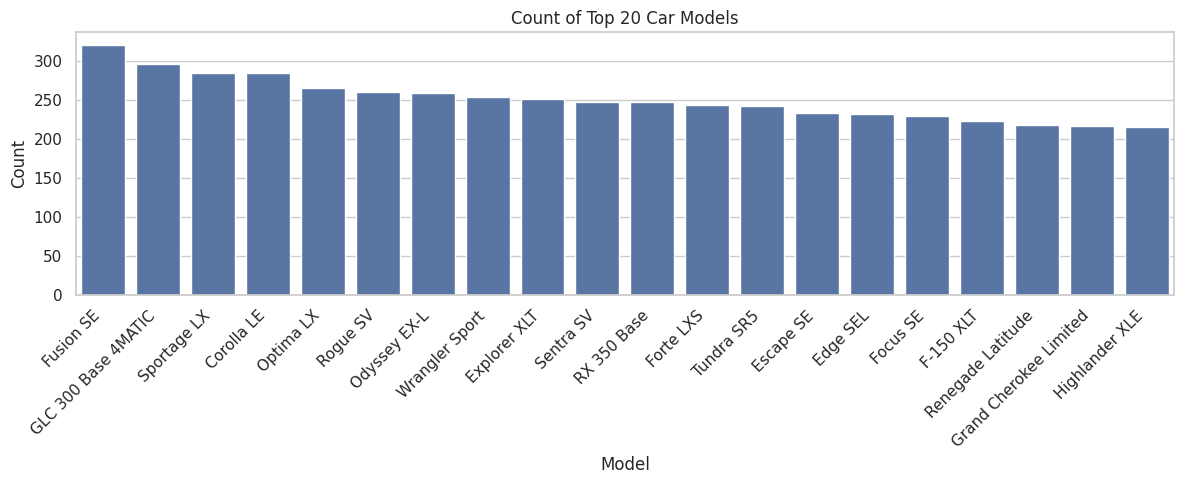

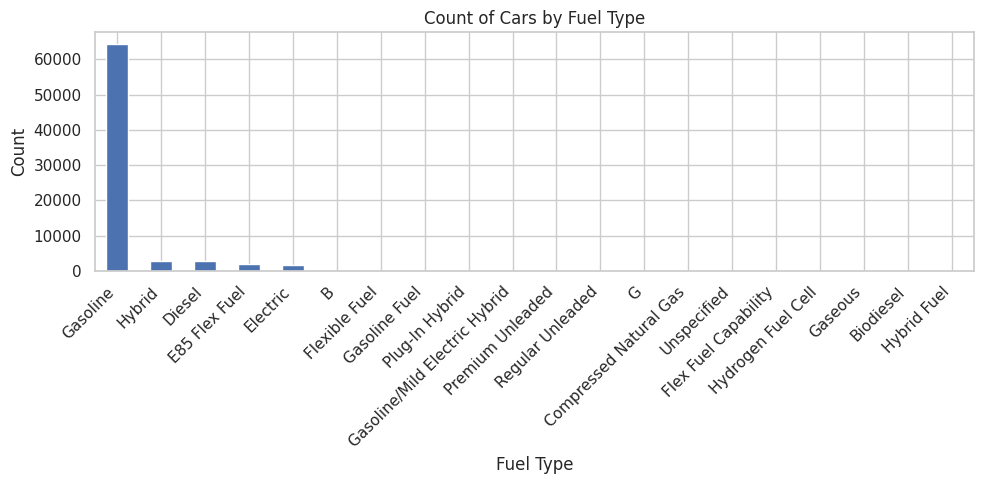

In [21]:
# Set general style for plots
sns.set(style='whitegrid')

# 1. Manufacturer count plot
plt.figure(figsize=(12, 5))
sns.countplot(data=df_no_outlier, x='manufacturer', order=df_no_outlier['manufacturer'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Cars by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Model count plot (top 20 to avoid overcrowding)
plt.figure(figsize=(12, 5))
top_models = df_no_outlier['model'].value_counts().nlargest(20).index
sns.countplot(data=df_no_outlier[df_no_outlier['model'].isin(top_models)], x='model', order=top_models)
plt.xticks(rotation=45, ha='right')
plt.title('Count of Top 20 Car Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Fuel Type count plot

plt.figure(figsize=(10, 5))
df_no_outlier['fuel_type'].value_counts().plot(kind='bar')
plt.title('Count of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
df_no_outlier.head ()

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,driver_rating,price
1905,Acura,TL 3.5,2013,107698,Gasoline,0,0,0,4.7,12695.0
5642,Acura,TLX A-Spec,2022,7863,Gasoline,0,1,1,4.8,41995.0
5735,Acura,TLX FWD,2016,66258,Gasoline,0,0,1,4.5,18498.0
8444,Acura,MDX Touring,2003,144352,Gasoline,1,1,1,4.4,6839.0
360,Acura,ILX Premium Package,2020,21086,Gasoline,0,1,1,4.6,22847.0


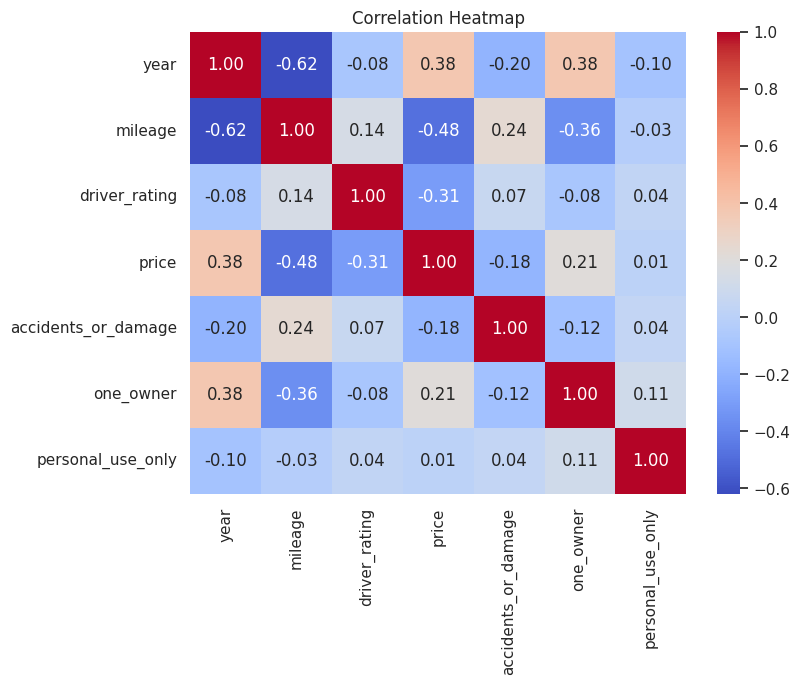

In [23]:
numeric_cols = ['year', 'mileage', 'driver_rating', 'price']
binary_cols = ['accidents_or_damage', 'one_owner', 'personal_use_only']

# Make sure the DataFrame variable name is correct here:
corr = df_no_outlier[numeric_cols + binary_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


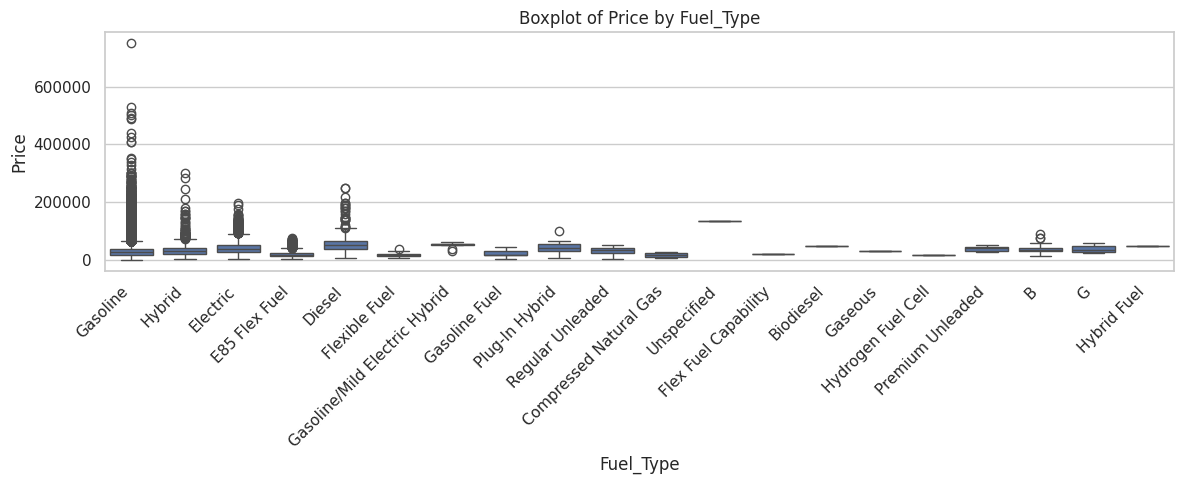

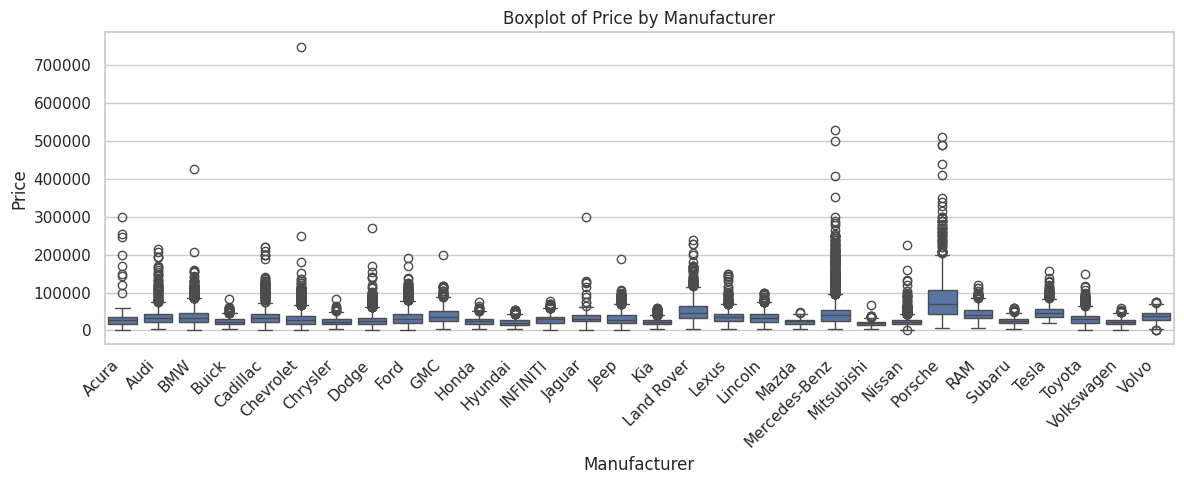

In [24]:
categorical_cols = ['fuel_type', 'manufacturer']

for col in categorical_cols:
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=col, y='price', data=df_no_outlier)
    plt.title(f'Boxplot of Price by {col.title()}')
    plt.xlabel(col.title())
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [25]:
# Combine manufacturer, model, and fuel_type into a new feature
df_no_outlier.loc[:, 'make_fuel'] = (
    df_no_outlier['manufacturer'].astype(str) + '_' +
    df_no_outlier['fuel_type'].astype(str)
)

# Preview the new column
df_no_outlier.head()

/tmp/ipython-input-25-3774275778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outlier.loc[:, 'make_fuel'] = (


,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,driver_rating,price,make_fuel
1905,Acura,TL 3.5,2013,107698,Gasoline,0,0,0,4.7,12695.0,Acura_Gasoline
5642,Acura,TLX A-Spec,2022,7863,Gasoline,0,1,1,4.8,41995.0,Acura_Gasoline
5735,Acura,TLX FWD,2016,66258,Gasoline,0,0,1,4.5,18498.0,Acura_Gasoline
8444,Acura,MDX Touring,2003,144352,Gasoline,1,1,1,4.4,6839.0,Acura_Gasoline
360,Acura,ILX Premium Package,2020,21086,Gasoline,0,1,1,4.6,22847.0,Acura_Gasoline


In [26]:
# Always make a copy to prevent SettingWithCopyWarning
df_no_outlier = df_no_outlier.copy()

# Now, add your new feature
max_year = df_no_outlier['year'].max()
df_no_outlier['Age'] = max_year - df_no_outlier['year']

# Preview the new column
df_no_outlier.head()
#df_no_outlier.info()


,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,driver_rating,price,make_fuel,Age
1905,Acura,TL 3.5,2013,107698,Gasoline,0,0,0,4.7,12695.0,Acura_Gasoline,10
5642,Acura,TLX A-Spec,2022,7863,Gasoline,0,1,1,4.8,41995.0,Acura_Gasoline,1
5735,Acura,TLX FWD,2016,66258,Gasoline,0,0,1,4.5,18498.0,Acura_Gasoline,7
8444,Acura,MDX Touring,2003,144352,Gasoline,1,1,1,4.4,6839.0,Acura_Gasoline,20
360,Acura,ILX Premium Package,2020,21086,Gasoline,0,1,1,4.6,22847.0,Acura_Gasoline,3


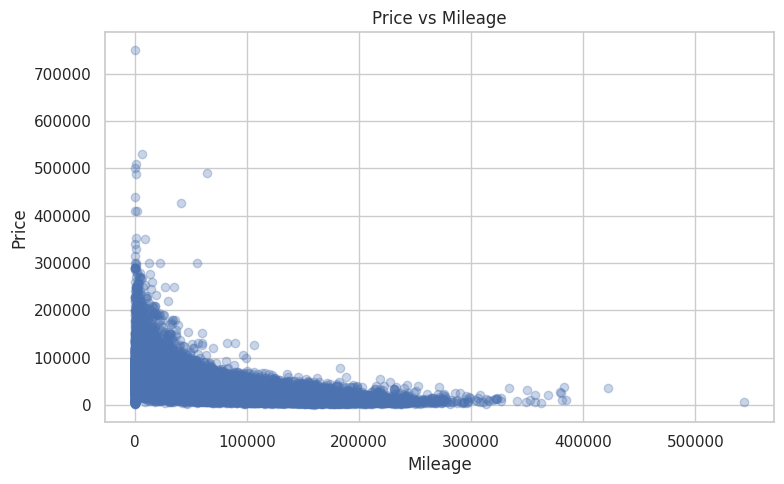

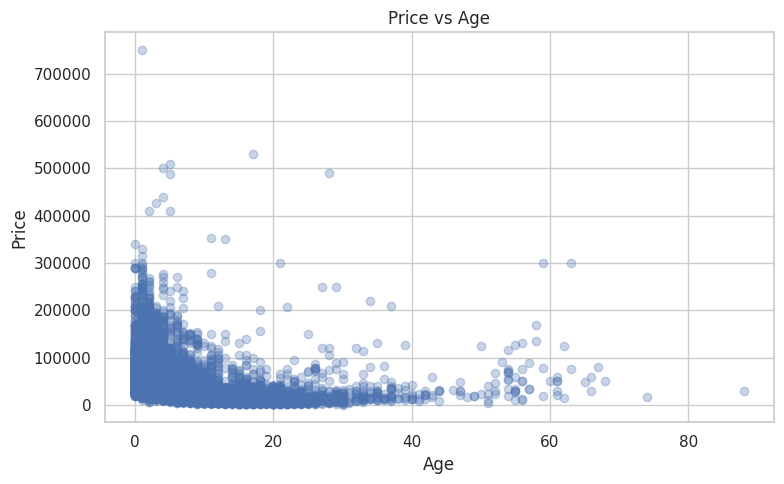

In [27]:
# Scatter plot: Price vs Mileage
plt.figure(figsize=(8, 5))
plt.scatter(df_no_outlier['mileage'], df_no_outlier['price'], alpha=0.3)
plt.title('Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Scatter plot: Price vs Age
plt.figure(figsize=(8, 5))
plt.scatter(df_no_outlier['Age'], df_no_outlier['price'], alpha=0.3)
plt.title('Price vs Age')
plt.xlabel('Age')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


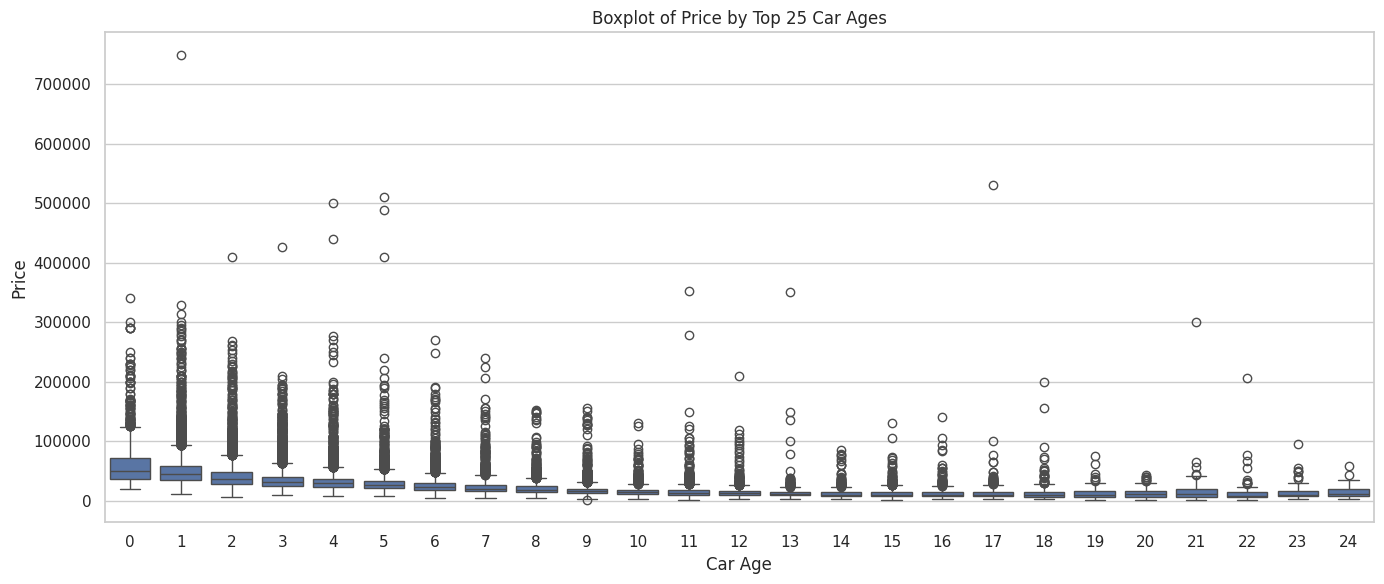

In [28]:
# Get the top 25 most common ages (just in case there are many unique values)
top_ages = df_no_outlier['Age'].value_counts().nlargest(25).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    x='Age',
    y='price',
    data=df_no_outlier[df_no_outlier['Age'].isin(top_ages)],
    order=sorted(top_ages)
)
plt.title('Boxplot of Price by Top 25 Car Ages')
plt.xlabel('Car Age')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


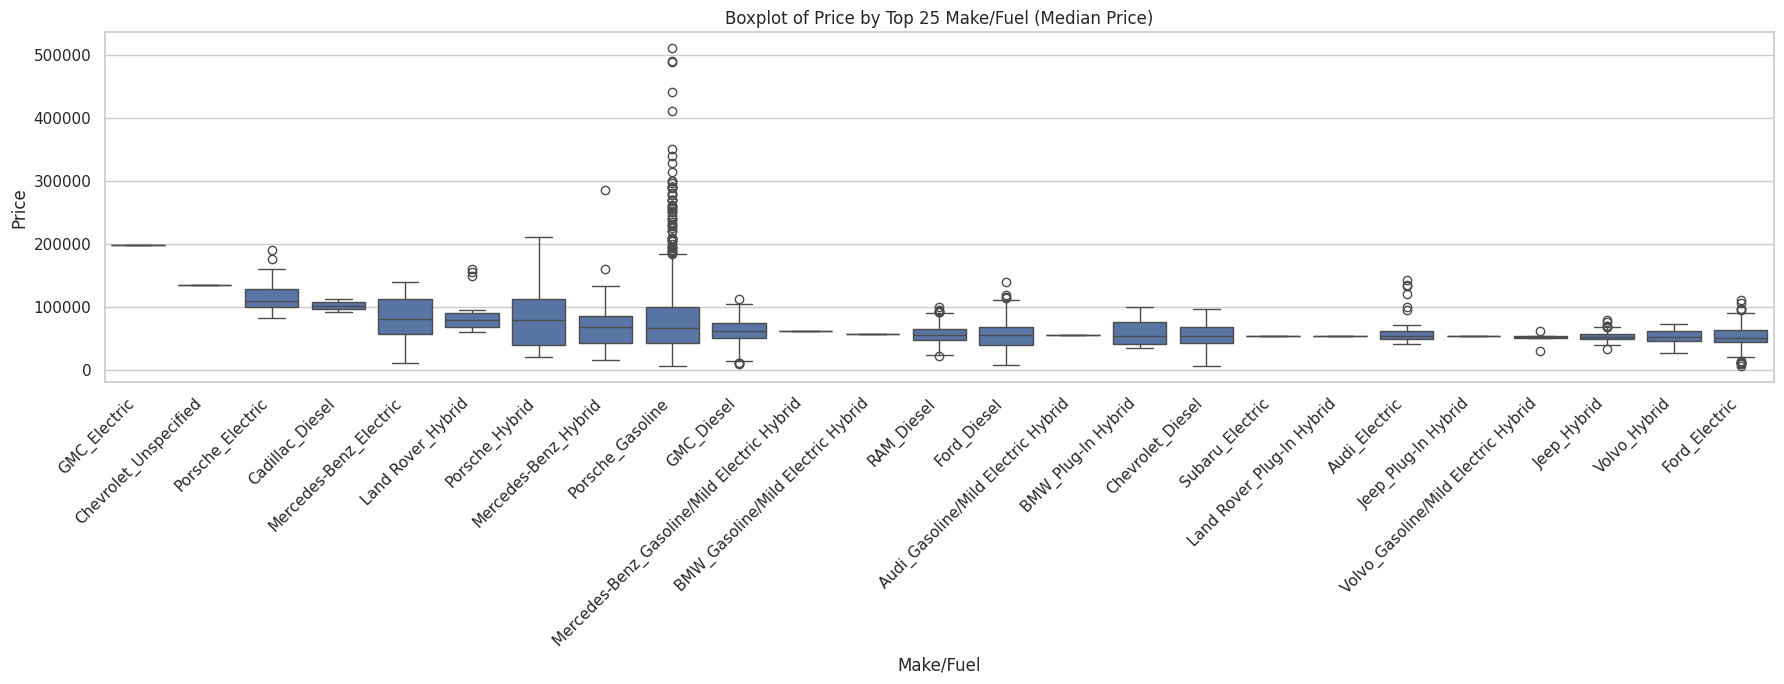

In [29]:
# Compute the median price per make_model_fuel
median_prices = df_no_outlier.groupby('make_fuel')['price'].median().sort_values(ascending=False)
top25_make_fuel = median_prices.head(25).index

plt.figure(figsize=(18, 7))
sns.boxplot(
    x='make_fuel',
    y='price',
    data=df_no_outlier[df_no_outlier['make_fuel'].isin(top25_make_fuel)],
    order=top25_make_fuel
)
plt.title('Boxplot of Price by Top 25 Make/Fuel (Median Price)')
plt.xlabel('Make/Fuel')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


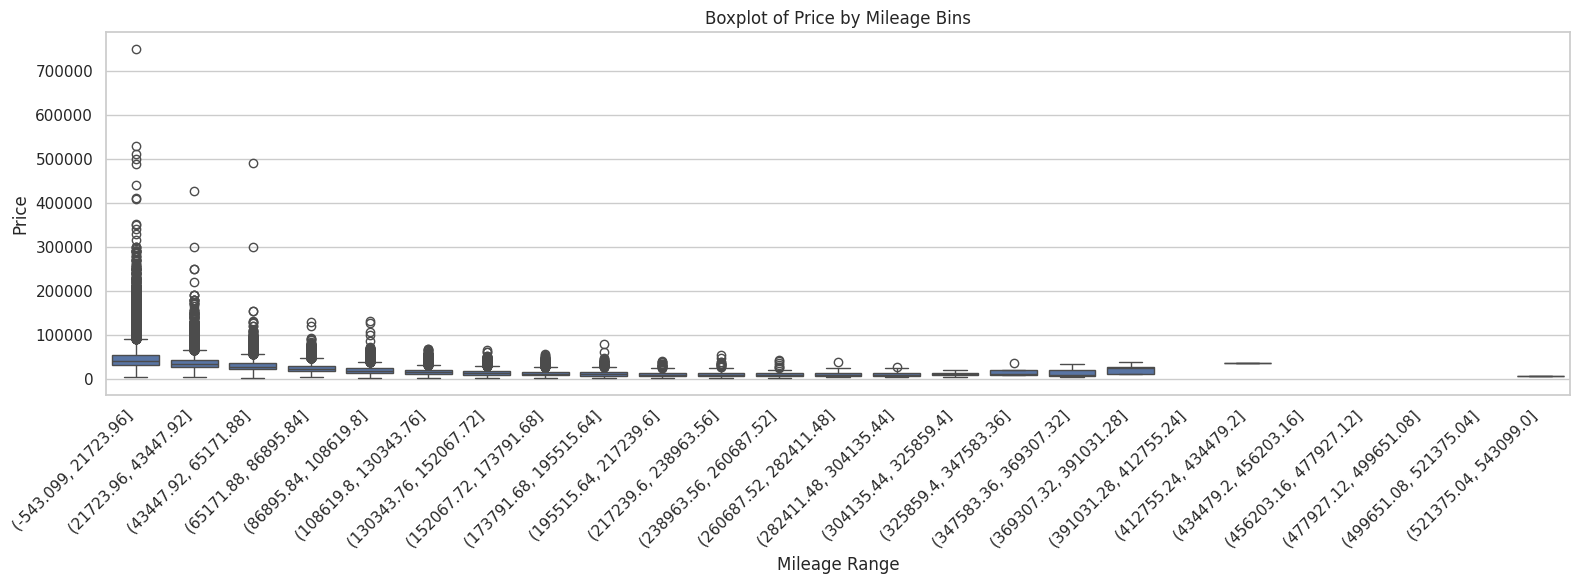

In [30]:
# Create mileage bins (e.g., every 20,000 km)
mileage_bins = pd.cut(df_no_outlier['mileage'], bins=25)  # You can adjust number of bins

plt.figure(figsize=(16, 6))
sns.boxplot(
    x=mileage_bins,
    y='price',
    data=df_no_outlier
)
plt.title('Boxplot of Price by Mileage Bins')
plt.xlabel('Mileage Range')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [31]:
# 1. Label encode high-cardinality columns
label_cols = ['make_fuel', 'model']
le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    df_no_outlier[col] = le.fit_transform(df_no_outlier[col])
    le_dict[col] = le  # Save encoders for reference if needed

# 2. One-hot encode low-cardinality columns
onehot_cols = ['fuel_type', 'manufacturer']
df_no_outlier = pd.get_dummies(df_no_outlier, columns=onehot_cols, drop_first=True)

# 3. Scale numerical columns
num_cols = ['mileage', 'Age', 'driver_rating']
scaler = StandardScaler()
df_no_outlier[num_cols] = scaler.fit_transform(df_no_outlier[num_cols])

# 4. Train-test split
X = df_no_outlier.drop('price', axis=1)
y = df_no_outlier['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (59040, 57)
X_test shape: (14761, 57)
y_train shape: (59040,)
y_test shape: (14761,)


In [32]:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Predict on train
    y_train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Predict on test
    y_test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    results[name] = {
        'Train MAE': train_mae,
        'Train RMSE': train_rmse,
        'Train R2': train_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2': test_r2
    }

    print(f"{name} --")
    print(f"  Train: MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, R2={train_r2:.3f}")
    print(f"  Test : MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, R2={test_r2:.3f}")

# Compare all results
results_df = pd.DataFrame(results).T
print("\nModel Performance (Train & Test):")
print(results_df)



Training Linear Regression...
Linear Regression --
  Train: MAE=9014.17, RMSE=15892.31, R2=0.488
  Test : MAE=8978.32, RMSE=15095.83, R2=0.504

Training Ridge Regression...
Ridge Regression --
  Train: MAE=9027.63, RMSE=15908.45, R2=0.487
  Test : MAE=8984.33, RMSE=15112.58, R2=0.503

Training Random Forest...
Random Forest --
  Train: MAE=1339.13, RMSE=3251.20, R2=0.979
  Test : MAE=3553.97, RMSE=7634.11, R2=0.873

Training XGBoost...
XGBoost --
  Train: MAE=3975.77, RMSE=6984.42, R2=0.901
  Test : MAE=4476.92, RMSE=8948.18, R2=0.826

Model Performance (Train & Test):
                     Train MAE    Train RMSE  Train R2     Test MAE  \
Linear Regression  9014.170315  15892.307659  0.487973  8978.318635   
Ridge Regression   9027.631307  15908.454134  0.486932  8984.329706   
Random Forest      1339.127885   3251.195975  0.978571  3553.972492   
XGBoost            3975.767387   6984.421762  0.901104  4476.917813   

                      Test RMSE   Test R2  
Linear Regression  1509

In [33]:
#Cross Validation
# 1. Defining models (all with default parameters)
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# 2. Initializing results dictionaries
cv_results = {}
holdout_results = {}

# 3. Applying Cross-validation and train/test performance
for name, model in models.items():
    print(f"\nEvaluating {name} ...")
    # Cross-validation (on training data)
    r2_cv = cross_val_score(model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    mae_cv = -cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    mse_cv = -cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_cv = np.sqrt(mse_cv)
    cv_results[name] = {
        'CV_R2_mean': np.mean(r2_cv),
        'CV_MAE_mean': np.mean(mae_cv),
        'CV_RMSE_mean': np.mean(rmse_cv)
    }
    print(f"  CV R2: {np.mean(r2_cv):.3f}, CV MAE: {np.mean(mae_cv):.2f}, CV RMSE: {np.mean(rmse_cv):.2f}")

    # Train and test performance (on actual splits)
    model.fit(X_train, y_train)
    # Train
    y_train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    # Test
    y_test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    holdout_results[name] = {
        'Train MAE': train_mae,
        'Train RMSE': train_rmse,
        'Train R2': train_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2': test_r2
    }
    print(f"  Train: MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, R2={train_r2:.3f}")
    print(f"  Test : MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, R2={test_r2:.3f}")

# 4. Display all results
print("\nCross-Validation Means (on Train data):")
cv_results_df = pd.DataFrame(cv_results).T
print(cv_results_df)

print("\nTrain/Test Performance on Actual Splits:")
holdout_results_df = pd.DataFrame(holdout_results).T
print(holdout_results_df)



Evaluating Linear Regression ...
  CV R2: 0.486, CV MAE: 9036.68, CV RMSE: 15922.74
  Train: MAE=9014.17, RMSE=15892.31, R2=0.488
  Test : MAE=8978.32, RMSE=15095.83, R2=0.504

Evaluating Ridge Regression ...
  CV R2: 0.485, CV MAE: 9047.06, CV RMSE: 15931.10
  Train: MAE=9027.63, RMSE=15908.45, R2=0.487
  Test : MAE=8984.33, RMSE=15112.58, R2=0.503

Evaluating Random Forest ...
  CV R2: 0.822, CV MAE: 3937.66, CV RMSE: 9373.29
  Train: MAE=1339.13, RMSE=3251.20, R2=0.979
  Test : MAE=3553.97, RMSE=7634.11, R2=0.873

Evaluating XGBoost ...
  CV R2: 0.785, CV MAE: 4583.42, CV RMSE: 10293.69
  Train: MAE=3975.77, RMSE=6984.42, R2=0.901
  Test : MAE=4476.92, RMSE=8948.18, R2=0.826

Cross-Validation Means (on Train data):
                   CV_R2_mean  CV_MAE_mean  CV_RMSE_mean
Linear Regression    0.485925  9036.680370  15922.735273
Ridge Regression     0.485380  9047.061329  15931.096476
Random Forest        0.821659  3937.659593   9373.286072
XGBoost              0.784914  4583.422042 

In [35]:
# Hyperparameter Tuning of Random Forest and XGBoost

# Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# XGBoost parameter grid (no change)
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Random Forest Tuning with RandomizedSearchCV (CV=3)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf,
    rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("\nBest Random Forest Params:", rf_search.best_params_)
print("Best RF 3-Fold CV MAE (train):", -rf_search.best_score_)

# XGBoost Tuning with RandomizedSearchCV (CV=3)
xgb = XGBRegressor(random_state=42, n_jobs=-1, tree_method='auto')
xgb_search = RandomizedSearchCV(
    xgb,
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("\nBest XGBoost Params:", xgb_search.best_params_)
print("Best XGB 3-Fold CV MAE (train):", -xgb_search.best_score_)

# Evaluate on train and test data for both models

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Train
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    # Test
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"\n{name} Performance:")
    print(f"Train -> MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R2: {train_r2:.3f}")
    print(f"Test  -> MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R2: {test_r2:.3f}")

# Best Random Forest
rf_best = rf_search.best_estimator_
evaluate_model("Random Forest", rf_best, X_train, y_train, X_test, y_test)

# Best XGBoost
xgb_best = xgb_search.best_estimator_
evaluate_model("XGBoost", xgb_best, X_train, y_train, X_test, y_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best RF 3-Fold CV MAE (train): 4849.518177696572
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best XGBoost Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best XGB 3-Fold CV MAE (train): 4136.470762101228

Random Forest Performance:
Train -> MAE: 2759.37, RMSE: 6000.23, R2: 0.927
Test  -> MAE: 4464.86, RMSE: 9037.47, R2: 0.822

XGBoost Performance:
Train -> MAE: 2133.19, RMSE: 3598.75, R2: 0.974
Test  -> MAE: 3836.19, RMSE: 8240.97, R2: 0.852


In [37]:
# Hyperparameter Tuning of Random Forest and XGBoost with increase Train dataset

# 1. 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Random Forest Tuning with RandomizedSearchCV (CV=3)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf,
    rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("\nBest Random Forest Params:", rf_search.best_params_)
print("Best RF 3-Fold CV MAE (train):", -rf_search.best_score_)

# XGBoost Tuning with RandomizedSearchCV (CV=3)
xgb = XGBRegressor(random_state=42, n_jobs=-1, tree_method='auto')
xgb_search = RandomizedSearchCV(
    xgb,
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("\nBest XGBoost Params:", xgb_search.best_params_)
print("Best XGB 3-Fold CV MAE (train):", -xgb_search.best_score_)

# Evaluate on train and test data for both models

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Train
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    # Test
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"\n{name} Performance:")
    print(f"Train -> MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R2: {train_r2:.3f}")
    print(f"Test  -> MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R2: {test_r2:.3f}")

# Best Random Forest
rf_best = rf_search.best_estimator_
evaluate_model("Random Forest", rf_best, X_train, y_train, X_test, y_test)

# Best XGBoost
xgb_best = xgb_search.best_estimator_
evaluate_model("XGBoost", xgb_best, X_train, y_train, X_test, y_test)


Train shape: (51660, 57)
Test shape: (22141, 57)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best RF 3-Fold CV MAE (train): 4975.599017851941
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best XGBoost Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best XGB 3-Fold CV MAE (train): 4208.17647491585

Random Forest Performance:
Train -> MAE: 2832.65, RMSE: 6204.56, R2: 0.923
Test  -> MAE: 4602.39, RMSE: 9256.01, R2: 0.814

XGBoost Performance:
Train -> MAE: 2084.61, RMSE: 3583.47, R2: 0.974
Test  -> MAE: 3941.78, RMSE: 8331.55, R2: 0.849


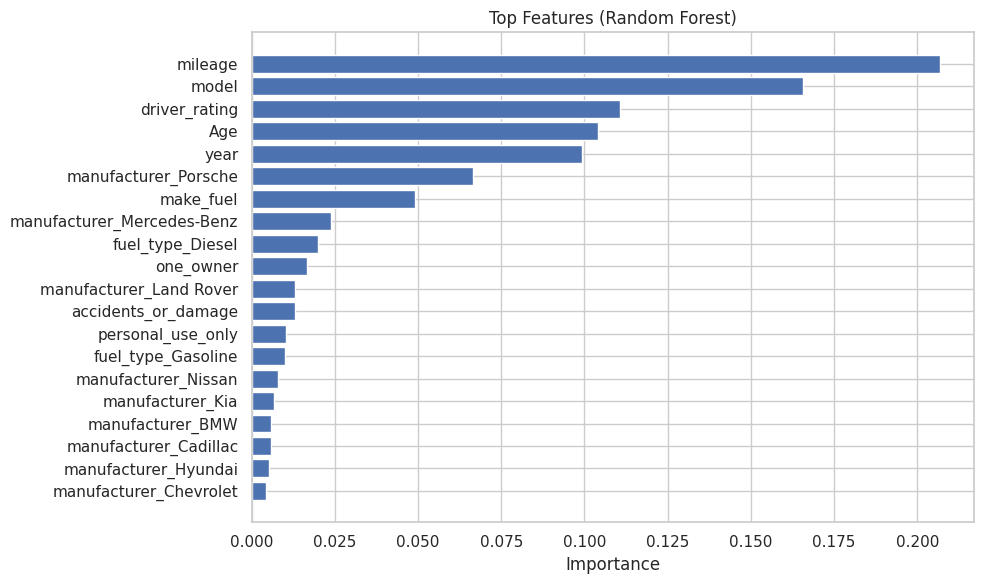

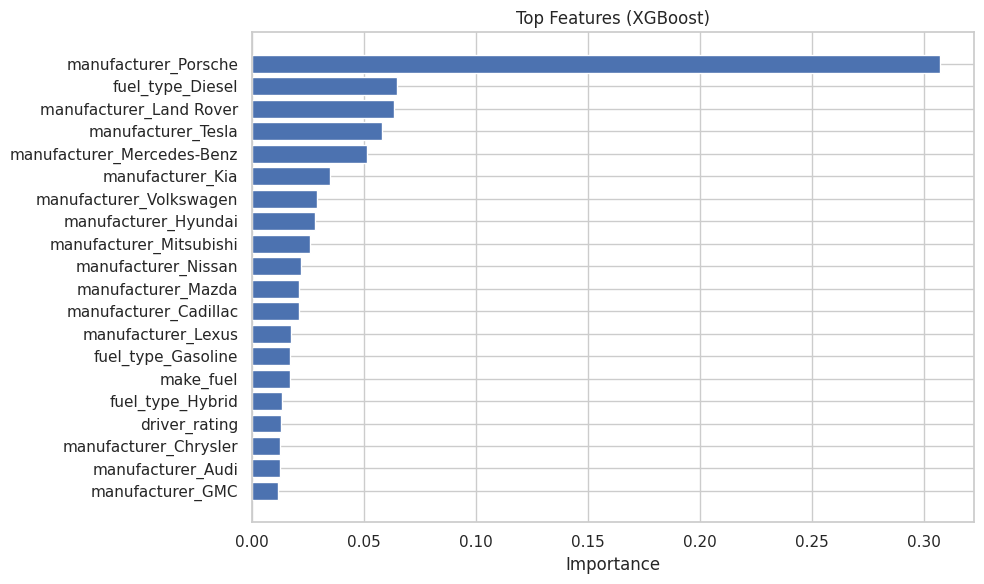

In [38]:
def get_top_features(model, X_train, top_n=20):
    # Get feature importances
    importances = model.feature_importances_
    features = X_train.columns
    # Create DataFrame and sort
    feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    return feat_imp_df.head(top_n)

# Top 20 for Random Forest
rf_top_features = get_top_features(rf_best, X_train)

# Top 20 for XGBoost
xgb_top_features = get_top_features(xgb_best, X_train)

def plot_top_features(feat_imp_df, model_name="Model"):
    plt.figure(figsize=(10,6))
    plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])  # reverse for descending order
    plt.xlabel('Importance')
    plt.title(f'Top Features ({model_name})')
    plt.tight_layout()
    plt.show()

# Plot for Random Forest
plot_top_features(rf_top_features, "Random Forest")

# Plot for XGBoost
plot_top_features(xgb_top_features, "XGBoost")


In [39]:
# After fitting xgb_search...
xgb_best = xgb_search.best_estimator_

# Use XGBoost for predictions
evaluate_model("XGBoost", xgb_best, X_train, y_train, X_test, y_test)

# Save the model
import pickle
with open('xgboost_best_model.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)



XGBoost Performance:
Train -> MAE: 2084.61, RMSE: 3583.47, R2: 0.974
Test  -> MAE: 3941.78, RMSE: 8331.55, R2: 0.849


In [40]:
import pickle

with open("xgboost_best_model.pkl", "wb") as f:
    pickle.dump(xgb_best, f)